# Task 4: Channel effectiveness, measured

**CLO1:** how the brain processes visual information.

I'm reproducing a tiny version of Cleveland & McGill: show a person two values encoded five ways and see which encoding they read most accurately. The five chart functions and the iris comparison run straight away. The 30-trial experiment needs a real person, so it's a function I run by hand and it writes `channel_results.csv`.

In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import clear_output

trials = pd.read_csv("channel_trials.csv")
print(trials.shape)
print(trials.groupby("channel").size().to_dict())

(30, 7)
{'angle': 6, 'area': 6, 'colour': 6, 'length': 6, 'position': 6}


## Step 1: five tiny chart functions
No axis labels, no tick values, no numbers. Position and length use a fixed 0 to 100 scale, so the two values sit on a *common* scale.

**On the area chart:** `ax.scatter(..., s=...)` takes **area**, not radius. I set `s = 22 * value`, so area is directly proportional to the value (a value twice as big gets twice the area). I did *not* use `s` proportional to value squared, which would have been the classic area lie.

**On the colour chart:** a single-hue sequential lightness ramp (`Greys`), darker = bigger. No rainbow.

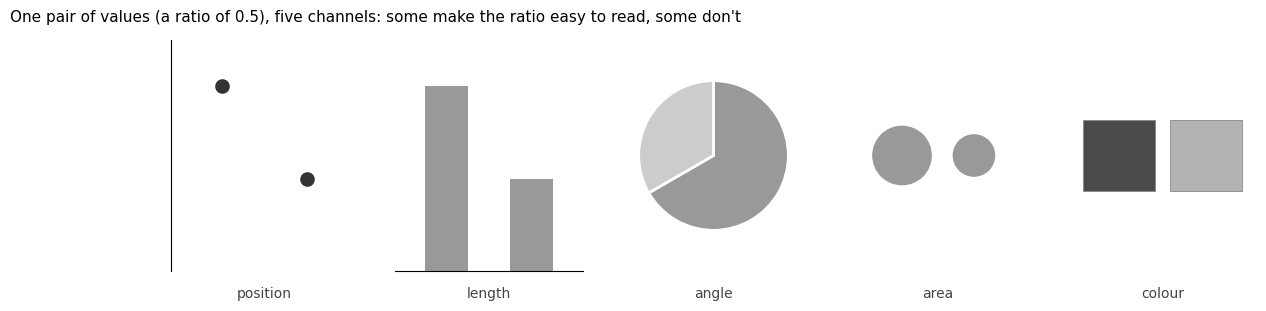

In [2]:
GREY = "#999999"
AREA_K = 22   # s = AREA_K * value  ->  area proportional to value (NOT value**2)

def draw_position(ax, vl, vs, swap=False):
    vals = [vs, vl] if swap else [vl, vs]
    ax.scatter([0, 1], vals, s=90, color="#333333", zorder=3)
    ax.set_xlim(-0.6, 1.6); ax.set_ylim(0, 100)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ("top", "right", "bottom"): ax.spines[s].set_visible(False)

def draw_length(ax, vl, vs, swap=False):
    vals = [vs, vl] if swap else [vl, vs]
    ax.bar([0, 1], vals, width=0.5, color=GREY)
    ax.set_xlim(-0.6, 1.6); ax.set_ylim(0, 100)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ("top", "right", "left"): ax.spines[s].set_visible(False)

def draw_angle(ax, vl, vs, swap=False):
    vals = [vs, vl] if swap else [vl, vs]
    ax.pie(vals, startangle=90, counterclock=False, colors=["#999999", "#cccccc"],
           wedgeprops=dict(edgecolor="white", linewidth=2))
    ax.set_aspect("equal")

def draw_area(ax, vl, vs, swap=False):
    vals = [vs, vl] if swap else [vl, vs]
    ax.scatter([0, 1], [0, 0], s=[AREA_K * v for v in vals], color=GREY)
    ax.set_xlim(-0.8, 1.8); ax.set_ylim(-1, 1)
    ax.axis("off")

def draw_colour(ax, vl, vs, swap=False):
    vals = [vs, vl] if swap else [vl, vs]
    ramp = lambda v: plt.cm.Greys(0.05 + 0.90 * v / 100)
    for i, v in enumerate(vals):
        ax.add_patch(Rectangle((i * 1.2, 0), 1, 1, facecolor=ramp(v), edgecolor="#888888", lw=0.6))
    ax.set_xlim(-0.2, 2.4); ax.set_ylim(-0.2, 1.2)
    ax.set_aspect("equal"); ax.axis("off")

DRAW = {"position": draw_position, "length": draw_length, "angle": draw_angle,
        "area": draw_area, "colour": draw_colour}

# check: same pair (large 80, small 40, ratio 0.5) in all five channels
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, (name, fn) in zip(axes, DRAW.items()):
    fn(ax, 80, 40)
    fig.text(ax.get_position().x0 + ax.get_position().width / 2, 0.02, name, ha="center", fontsize=10, color="#444444")
fig.suptitle("One pair of values (a ratio of 0.5), five channels: some make the ratio easy to read, some don't",
             x=0.01, ha="left", fontsize=11)
fig.savefig("t4_five_channels.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 2 and 3: run all 30 trials, compute the error
The 30 trials are shuffled with my own seed (not the data seed). Which side the larger value sits on is also randomised. The reader doesn't see the true answers until the end. The question is exactly: "the smaller one is what percentage of the larger?"

`absolute_error = abs(reader_estimate / 100 - true_ratio)`, saved to `channel_results.csv`.

To run: set `RUN_EXPERIMENT = True`, hand them the keyboard.

In [3]:
RUN_EXPERIMENT = False
READER = "a classmate"

def run_channel_experiment(reader):
    rnd = random.Random(11)
    order = list(trials.index)
    rnd.shuffle(order)
    out = trials.copy()
    out["reader"] = reader
    for k, idx in enumerate(order, 1):
        row = trials.loc[idx]
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(3.2, 3.2))
        DRAW[row.channel](ax, row.value_large, row.value_small, swap=rnd.random() < 0.5)
        plt.show()
        est = ""
        while True:
            est = input(f"[{k}/30] The smaller one is what percentage of the larger? (1-100): ").strip()
            try:
                if 1 <= float(est) <= 100:
                    break
            except ValueError:
                pass
        out.loc[idx, "reader_estimate"] = float(est)
    out["absolute_error"] = (out.reader_estimate / 100 - out.true_ratio).abs()
    clear_output()
    out.to_csv("channel_results.csv", index=False)
    print("saved channel_results.csv")
    return out

if RUN_EXPERIMENT:
    run_channel_experiment(READER)

**Who was my reader:** _(first name, anything relevant)_

**What I asked:** "The smaller one is what percentage of the larger?" for each of the 30 charts, shuffled, no numbers shown, answers revealed at the end.

## Step 4: rank the channels by mean absolute error
One bar per channel, sorted, zero baseline, error bars = standard error across that channel's six trials. The channel with the smallest error is the pop-out. Bars are labelled directly with their mean error.

In [4]:
GOLD = ["position", "length", "angle", "area", "colour"]   # published order (volume wasn't tested)
if os.path.exists("channel_results.csv"):
    res = pd.read_csv("channel_results.csv")
    agg = res.groupby("channel").absolute_error.agg(["mean", "std", "count"])
    agg["sem"] = agg["std"] / np.sqrt(agg["count"])
    agg = agg.sort_values("mean")
    best, worst = agg.index[0], agg.index[-1]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i, (name, r) in enumerate(agg.iterrows()):
        ax.barh(i, r["mean"], xerr=r["sem"], color="#ee6677" if name == best else "#bbbbbb",
                error_kw=dict(ecolor="#555555", capsize=3))
        ax.text(r["mean"] + r["sem"] + 0.005, i, f"{name}  ({r['mean']*100:.1f} pts)", va="center", fontsize=9)
    ax.set_yticks([]); ax.invert_yaxis()
    ax.set_xlim(0, (agg["mean"] + agg["sem"]).max() * 1.45)
    ax.set_xlabel("Mean absolute error (fraction of the ratio; 0.10 = ten percentage points)")
    ax.set_title(f"For this reader, {best} was read most accurately and {worst} least", loc="left", fontsize=11)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.text(0, -0.22, f"n = {len(res)} estimates from 1 reader ({READER}), 6 per channel. Bars = mean, whiskers = standard error. No trials excluded.",
            transform=ax.transAxes, fontsize=8, color="#666666")
    fig.savefig("t4_channel_ranking.png", dpi=300, bbox_inches="tight")
    plt.show()
    mine = list(agg.index)
    cmp_ = pd.DataFrame({"published_rank": [GOLD.index(c) + 1 for c in mine],
                         "my_rank": range(1, 6),
                         "mean_error_pts": (agg["mean"] * 100).round(1).values}, index=mine)
    d2 = ((cmp_.published_rank - cmp_.my_rank) ** 2).sum()
    print(cmp_)
    print("\nSpearman rank correlation with the published order:", round(1 - 6 * d2 / (5 * 24), 2))
else:
    print("channel_results.csv doesn't exist yet. Run the experiment (RUN_EXPERIMENT = True) and re-run.")

channel_results.csv doesn't exist yet. Run the experiment (RUN_EXPERIMENT = True) and re-run.


**Where mine agrees and disagrees (write this after you see the table).** The published order is position > length > angle > area > volume > colour. I didn't test volume, so I'm comparing five. Say which channels landed where the theory says and which didn't. Be straight about the ones that didn't. With six trials per channel one odd answer can swap two neighbours. In particular, the ratios here are 0.15, 0.25, 0.40, 0.55, 0.70, 0.85, and people are known to round to "nice" fractions like 25%, 50%, which makes some trials easier than they look.

_Your result here: ___

## Step 5: the same finding on iris, in a high-ranking and a low-ranking channel
The finding: **setosa flowers have far shorter petals than the other two species.** Same species columns in both charts. Left, `petal_length` goes on **position** (rank 1 for quantity). Right, `petal_length` goes on **colour lightness** (the bottom of the ranking), and the vertical position inside each column is just random jitter that carries nothing.

The one pop-out in the left chart is setosa (strong colour); the other two species are grey. Species are named directly on the x-axis, so colour isn't carrying that alone. The right chart has no pop-out at all: a sequential ramp is the only way to show quantity with colour.

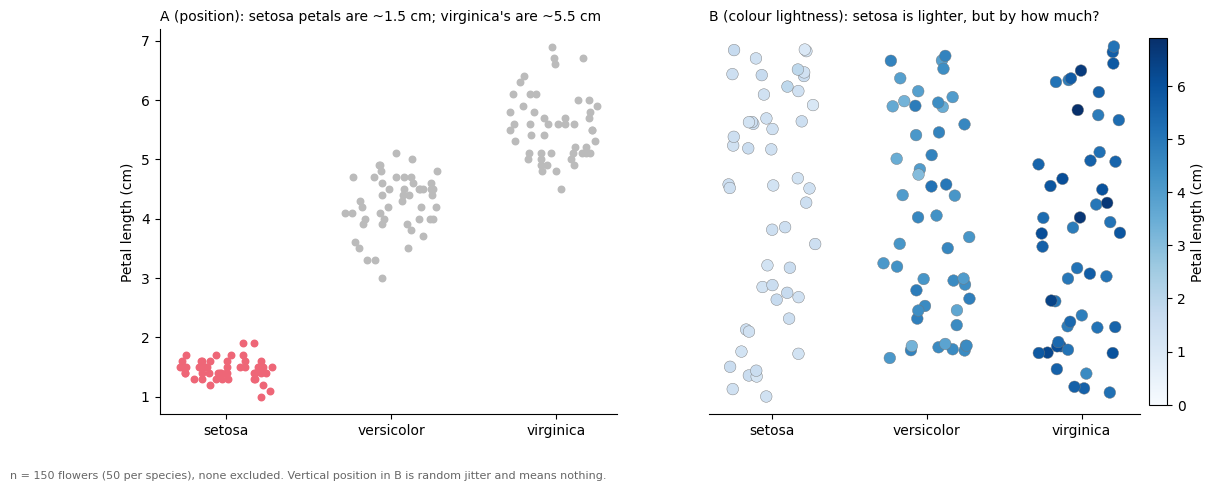

In [5]:
iris = pd.read_csv("iris.csv")
order = ["setosa", "versicolor", "virginica"]
med = iris.groupby("species").petal_length.median()
rng = np.random.default_rng(5)
xj = {sp: i + rng.uniform(-0.28, 0.28, (iris.species == sp).sum()) for i, sp in enumerate(order)}

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5))
for i, sp in enumerate(order):
    d = iris[iris.species == sp]
    a.scatter(xj[sp], d.petal_length, s=22, color="#ee6677" if sp == "setosa" else "#bbbbbb")
a.set_xticks(range(3)); a.set_xticklabels(order)
a.set_ylabel("Petal length (cm)")
a.set_title(f"A (position): setosa petals are ~{med['setosa']:.1f} cm; virginica's are ~{med['virginica']:.1f} cm", loc="left", fontsize=10)
for s in ("top", "right"): a.spines[s].set_visible(False)

vmin, vmax = iris.petal_length.min(), iris.petal_length.max()
for i, sp in enumerate(order):
    d = iris[iris.species == sp]
    yy = np.random.default_rng(9 + i).uniform(0, 1, len(d))
    sc = b.scatter(xj[sp], yy, s=70, c=d.petal_length, cmap="Blues", vmin=vmin - 1, vmax=vmax,
                   edgecolor="#777777", linewidth=0.3)
b.set_xticks(range(3)); b.set_xticklabels(order)
b.set_yticks([])
b.set_title("B (colour lightness): setosa is lighter, but by how much?", loc="left", fontsize=10)
for s in ("top", "right", "left"): b.spines[s].set_visible(False)
cb = fig.colorbar(sc, ax=b, fraction=0.04, pad=0.02)
cb.set_label("Petal length (cm)")
fig.text(0.01, -0.02, f"n = {len(iris)} flowers (50 per species), none excluded. Vertical position in B is random jitter and means nothing.",
         fontsize=8, color="#666666")
fig.savefig("t4_iris_two_channels.png", dpi=300, bbox_inches="tight")
plt.show()

**Which one I'd publish: A.** In A the reader judges a *distance* along a shared scale, so "about 1.5 versus about 5.5" is something they can read to roughly the nearest half centimetre and see that one is more than three times the other. In B the reader has to match a shade against the colour bar, and shades next to each other change how they look, so most people can say "lighter" but can't say "three times". Both charts carry the same data and the same message. The difference is how accurately the reader can decode it, and that is the whole case for A. B also needs a colour bar, which is an extra lookup the reader has to hold in working memory (extraneous load).

## The question: what can my experiment support, and why still trust the published ranking?
**What it can support.** It's 30 estimates from one person, 6 per channel. That's enough to see whether one channel produced very obviously worse answers for *this* reader and to practise the method. It can't support a general claim about "people", can't tell a real difference between two close channels from noise (the standard error whiskers overlap), and can't separate the channel's effect from this reader's habits, like rounding to 25/50/75, or from the order of the trials. There's no statistical power here. I'm not going to put a p-value on it.

**Why follow the published ranking anyway.** Cleveland and McGill's result comes from many participants and many trials, with the order and layout controlled, and it has been repeated by later work (Heer & Bostock, among others). It also has a mechanism behind it: we compare positions and lengths against a shared scale, but we have to *estimate* angles and areas, and shade is judged relative to its surroundings. My six-trial sample disagreeing with that is much more likely to be noise than a discovery. So when I choose a channel for something a reader has to read off accurately, I follow the ranking, and I treat my own small result as a demonstration of it, not as evidence against it.